まず必要なライブラリをインポートする

In [ ]:
import os
import time
import csv
import json
import tifffile
from datetime import datetime
import matplotlib.pyplot as plt
import numpy as np
import numpy.linalg as la
from scipy import interpolate, signal
from scipy.optimize import least_squares
import pandas as pd
import seaborn as sns
import subprocess
#from osgeo import gdal, osr, gdalconst, gdal_array

In [2]:
# read radiometric file (csv)
def read_bfile(file):
    # ファイルのベース名に“_B.csv”を追加して新しいファイル名を作成
    fileb = os.path.splitext(file)[0] + "_B.csv"
    # CSVファイルをpandasを使って読み込む
    df = pd.read_csv(fileb)
    # パラメータ配列を初期化
    param = np.zeros((185, 5), dtype=float)
    # DataFrameからデータを抽出し、param配列に格納
    for i in range(min(185, len(df))):  # レコード数が185を超えないようにする
        for j in range(5):
            param[i, j] = float(df.iloc[i, j + 1])
    #‘CenterWavelengthNanometer’, ‘FullWidthAtHalfMaximumNanometer’,
    #‘SolarIrradianceWatt/Meter2/Micron’, ‘ReflectanceMulti’, ‘ReflectanceAdd’
    return param

# read meta data (txt)
def read_tfile(file):
    fileb = os.path.splitext(file)[0]  # ファイルの拡張子を削除し、ベース名を取得
    fileb = fileb + ".txt"  # ベース名に“.txt”を追加して、新しいファイル名を作成
    csv_file = open(fileb, "r")  # txtファイルを読み取りモードで開く
    record_list = []  # レコードを格納するリストを初期化
    record = csv_file.readline()  # 2行目から読み込みを開始
    while record :  # ファイルの終わりまでループ
        record_list.append(record.rstrip().split("="))  # 各行を読み込み、改行文字を取り除き‘=’で分割してリストにし、record_listに追加
        record = csv_file.readline()  # 次の行を読み込む
    for record in record_list:  # 全レコードをループ
        if(record[0]=="RadianceMultiVNIR                                                      "):
            radiancemultivnir = float(record[1])
        if(record[0]=="RadianceAddVNIR                                                        "):
            radianceaddvnir = float(record[1])
        if(record[0]=="RadianceMultiSWIR                                                      "):
            radiancemultiswir = float(record[1])
        if(record[0]=="RadianceAddSWIR                                                        "):
            radianceaddswir = float(record[1])
    return radiancemultivnir, radiancemultiswir, radianceaddvnir, radianceaddswir

# 入力画像に放射補正を適用
def apply_radiometric(img, radmultivnir, radmultiswir, radaddvnir, radaddswir):
    im = np.ones([img.shape[0], img.shape[1]])  # 画像の高さと幅に基づいて、全ての要素が1のマスクを作成
    # no data area
    im[img[:,:,10] == 0] = 0  # 画像のバンド10が0の位置に対して、マスクを0に設定（データがない領域を示す）
    # change to float
    img = 1.0 * img  # 入力画像を浮動小数点数型に変換
    # apply radiometric vnir
    for j in range(58):  # 0から57バンド（VNIR領域）に対して、放射補正を適用
        img[:,:,j] = img[:,:,j] * radmultivnir + radaddvnir  # 各バンドの値にradmultivnirを掛けてradaddvnirを加える
    # apply radiometric swir
    for j in range(58, 185):  # 58から184バンド（SWIR領域）に対して、放射補正を適用
        img[:,:,j] = img[:,:,j] * radmultiswir + radaddswir  # 各バンドの値にradmultiswirを掛けてradaddswirを加える
    img[im == 0] = 0  # マスクが0の位置（データがない領域）に対して、画像の値を0に設定
    return img

# ピクセル空間から地理空間への変換
def show_xy(src, x, y):
    width = src.RasterXSize # srcラスターデータセットの横幅（列数）を取得し格納
    height = src.RasterYSize # srcラスターデータセットの縦幅（行数）を取得し格納
    gt = src.GetGeoTransform() # srcラスターデータセットのジオトランスフォーム（地理変換情報）を取得し、gtに格納
    # gtは6つの要素を持つタプルで、地理座標への変換情報を含む
    # gt[0]: 左上隅のX座標（地理座標系の原点のX座標）。
    # gt[1]: 水平方向のピクセル解像度（ピクセルサイズ、X方向のスケール）。
    # gt[2]: 水平方向の回転（通常は0）。
    # gt[3]: 左上隅のY座標（地理座標系の原点のY座標）。
    # gt[4]: 垂直方向の回転（通常は0）。
    # gt[5]: 垂直方向のピクセル解像度（ピクセルサイズ、Y方向のスケール。通常は負の値、地図の上が北である場合）。
    minx = gt[0]
    miny = gt[3] + width * gt[4] + height * gt[5]
    maxx = gt[0] + width * gt[1] + height * gt[2]
    maxy = gt[3]
    X = gt[0] + x * gt[1] + y * gt[2]
    Y = gt[3] + x * gt[4] + y * gt[5]
    return X, Y

# 地理空間から緯度経度(WGS84)に変換
#def show_latlon(src, x, y):
    old_cs= osr.SpatialReference() # 元の座標系を入れるオブジェクト
    old_cs.ImportFromWkt(src.GetProjectionRef()) # データセットから取得した投影情報（WKT形式）
    # WGS84座標系のWKT（Well-Known Text）表現を文字列として定義
    wgs84_wkt = """
        GEOGCS["WGS 84",
            DATUM["WGS_1984",
                SPHEROID["WGS 84",6378137,298.257223563,
                    AUTHORITY["EPSG","7030"]],
                AUTHORITY["EPSG","6326"]],
            PRIMEM["Greenwich",0,
                AUTHORITY["EPSG","8901"]],
            UNIT["degree",0.01745329251994328,
                AUTHORITY["EPSG","9122"]],
            AUTHORITY["EPSG","4326"]]"""
    new_cs = osr.SpatialReference() # 新しい座標系を入れるオブジェクト
    new_cs .ImportFromWkt(wgs84_wkt) # 定義したWGS84のWKT文字列をインポート
    # old_csからnew_csへの座標変換を行うためのosr.CoordinateTransformationオブジェクトを作成し、transformに格納
    transform = osr.CoordinateTransformation(old_cs,new_cs)
    X, Y = show_xy(src, x, y) #ピクセル空間から地理空間への変換
    # 計算した地理座標XとYを、transformを使ってWGS84座標系（緯度経度）に変換、格納します
    latlong = transform.TransformPoint(X, Y)
    return latlong

# ハイパースペクトル画像から特定のバンドを取り出して表示するための関数
def get_rgb(img, b=8, g=18, r=28):
    ims = np.zeros([img.shape[0], img.shape[1], 3])  # 画像の高さ、幅、およびRGBの3チャンネルを持つゼロ配列を作成
    ims[:,:,0] = img[:,:,r]    #R
    ims[:,:,1] = img[:,:,g]    #G
    ims[:,:,2] = img[:,:,b]    #B
    max = np.max(ims)/3  # 画像配列の最大値を取得
    ims /= max   # 画像を max で割って正規化
    ims = np.clip(ims, 0.0, 1.0)  # 画像配列の値を0から255の範囲にクランプ
    #RGBの強さは小数点の場合0から1, 整数の場合は0から255の範囲にある必要がある。
    return ims
    
def show_img(img):
    fig, ax = plt.subplots()  # fig と ax を定義
    im = ax.imshow(img)  # 画像を表示
    plt.show()
    
#SWIRのデータを抽出
def get_radiance(img, param, y, x):
    wave = param[58:185,0]
    rad = img[y, x, 58:185]
    list_data = [wave, rad]
    list_data_T = np.array(list_data).T
    return list_data_T

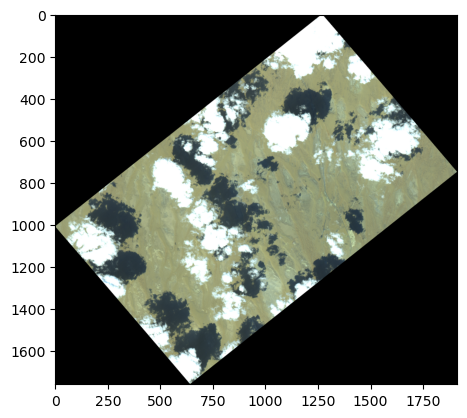

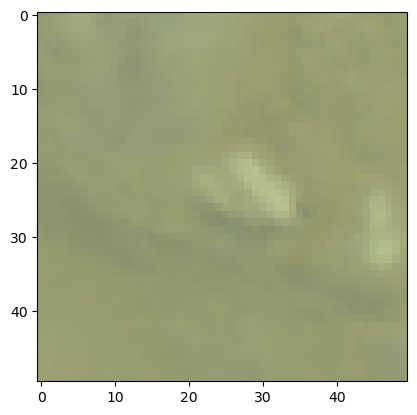

In [ ]:
# ファイルの読み込み
file = r"C:\Users\yudon\OneDrive\デスクトップ\メタン\2025_HISUI_1_地獄の門\HSHL1G_N402E0583_20210803092156_20240106123056\HSHL1G_N402E0583_20210803092156_20240106123056.tif"

directory = r'C:\Users\Public\Documents\MODTRAN6\matusoka\analysis\CHIBA_20210806\MODTRAN\single' 
img = tifffile.imread(file) # read tif file
param = read_bfile(file)    # read radiometric file (..._B.csv)
radmultivnir, radmultiswir, radaddvnir, radaddswir = read_tfile(file)  # read meta file (....txt)
img = apply_radiometric(img, radmultivnir, radmultiswir, radaddvnir, radaddswir)  # apply radiometric parameter
ims = get_rgb(img, b=8, g=18, r=28)
center = np.array([1410, 700]) #中心座標(y, x), ここを変える
#ここで切り取りの範囲を設定
img_slice = img[center[0] - 25 : center[0] + 25, center[1] -25 : center[1] + 25, :] #補正後の画像
ims_slice = ims[center[0] - 25 : center[0] + 25, center[1] -25 : center[1] + 25 , :] #画像表示用の画像
show_img(ims)
show_img(ims_slice)

In [ ]:
# ファイルの読み込み, gdalができた後
#directory = r'C:\Users\Public\Documents\MODTRAN6\matusoka\analysis\CHIBA_20210806\MODTRAN\VIS20km' 
#file = ("C:\\Users\\Public\\Documents\\MODTRAN6\\matusoka\\analysis\\N364E1406_20210409\\HISUI\\HSHL1G_N364E1406_20210409012733_20221023064930.tif")
#src = gdal.Open(file, gdalconst.GA_ReadOnly)  # read geotiff file
#type(src) # “osgeo.gdal.Dataset”
#img = src.ReadAsArray()
#img = img.transpose(1, 2, 0)
#param = read_bfile(file)
#radmultivnir, radmultiswir, radaddvnir, radaddswir = read_tfile(file)
#img = apply_radiometric(img, radmultivnir, radmultiswir, radaddvnir, radaddswir)
#enter = np.array([1410, 660]) #中心座標, ここを変える
#一部を切り取る
#img_slice = img[center[0] - 10 : center[0] + 10, center[1] -10 : center[1] + 10, :] #ここで切り取りの範囲を設定
#lat, lon, nu = show_latlon(src, center[0], center[1])
#print("The center is ", center, "lat", lat, "lon", lon) #中心座標での緯度経度
#how_hyper(img, b=8, g=18, r=28)
#how_hyper(img_slice, b=8, g=18, r=28)

MODTRANのシミュレーション

In [4]:
# read meta data (txt)
def read_txt_inf(file):
    fileb = os.path.splitext(file)[0]  # ファイルの拡張子を削除し、ベース名を取得
    fileb = fileb + ".txt"  # ベース名に“.txt”を追加して、新しいファイル名を作成
    csv_file = open(fileb, "r")  # txtファイルを読み取りモードで開く
    record_list = []  # レコードを格納するリストを初期化
    record = csv_file.readline()  # 2行目から読み込みを開始
    while record :  # ファイルの終わりまでループ
        record_list.append(record.rstrip().split("="))  # 各行を読み込み、改行文字を取り除き‘=’で分割してリストにし、record_listに追加
        record = csv_file.readline()  # 次の行を読み込む
    for record in record_list:  # 全レコードをループ
        if(record[0]=="SceneCenterTime                                                        "):  #シーン中心観測時刻(UTC)
            scenecentertime = record[1]
        if(record[0]=="IlluminationElevationAngleDegree                                       "):  #太陽迎角
            illuminationelevation = float(record[1])
        if(record[0]=="IlluminationAzimuthAngleDegree                                         "):  #太陽方位角
            illuminationazimuth = float(record[1])
        if(record[0]=="SpacecraftElevationAngleDegree                                         "):  #人工衛星迎角
            spacecraftelevation = float(record[1])
        if(record[0]=="SpacecraftAzimuthAngleDegree                                           "):  #人工衛星方位角
            spacecraftazimuth = float(record[1])

    dt = datetime.strptime(scenecentertime, " %Y-%m-%dT%H:%M:%S.%fZ") # 文字列をdatetimeオブジェクトに変換
    iday = dt.timetuple().tm_yday # 年間通算日（Julian Day）を取得
    gmtime = dt.hour + dt.minute / 60 + dt.second / 3600  # 時間を10進法で表現
    bckzen = 90 - spacecraftelevation
    farsa = (illuminationazimuth + spacecraftazimuth) % 360  #Final altitude relative solar azimuth
    fasza = 90 - illuminationelevation  #Final altitude solar zenith angle
    return iday, gmtime, bckzen, farsa, fasza

IDAY, GMTIME, BCKZEN, PARM1, PARM2 = read_txt_inf(file)

In [6]:
for i in range(0, 30):
    json_open = open(r"C:\Users\Public\Documents\MODTRAN6\matusoka\example\sample\sample.json")
    json_load = json.load(json_open) #サンプルコードを持ってくる
    num = f"{0.25 * i :.2f}" #0.25ずつH20を増やす
    num_str = str(num)
    num_str = num_str.replace('.', 'p')
    file_name = num_str + '_440ppm'
    file_name_csv = file_name + '.csv' 
    file_name_json = file_name + '.json' 
    file_path = os.path.join(directory, "H2O", file_name)  
    os.makedirs(file_path, exist_ok=True) #新しくフォルダを作成
    json_load['MODTRAN'][0]['MODTRANINPUT']['NAME'] = file_name #sampleのファイル名を変更
    json_load['MODTRAN'][0]['MODTRANINPUT']['DESCRIPTION'] = '' #sampleの説明を変更
    json_load['MODTRAN'][0]['MODTRANINPUT']['RTOPTIONS']['IMULT'] = "RT_NO_MULTIPLE_SCATTER"
    del json_load['MODTRAN'][0]['MODTRANINPUT']['RTOPTIONS']['NSTR']
    del json_load['MODTRAN'][0]['MODTRANINPUT']['RTOPTIONS']['DISALB']
    json_load['MODTRAN'][0]["MODTRANINPUT"]['ATMOSPHERE']['H2OSTR'] = float(num) #sampleのH20量を変更
    json_load['MODTRAN'][0]['MODTRANINPUT']['GEOMETRY']["BCKZEN"] = BCKZEN
    json_load['MODTRAN'][0]['MODTRANINPUT']['GEOMETRY']['IDAY'] = IDAY
    json_load['MODTRAN'][0]['MODTRANINPUT']['GEOMETRY']["PARM1"] = PARM1
    json_load['MODTRAN'][0]['MODTRANINPUT']['GEOMETRY']["PARM2"] = PARM2
    json_load['MODTRAN'][0]['MODTRANINPUT']['GEOMETRY']["GMTIME"] = GMTIME
    json_load['MODTRAN'][0]['MODTRANINPUT']['SURFACE']['TPTEMP'] = 305
    json_load['MODTRAN'][0]["MODTRANINPUT"]['FILEOPTIONS']['CSVPRNT'] = file_name_csv #sampleのcsvファイル名を変更
    json_path = os.path.join(directory, "H2O", file_name, file_name_json)  
    with open(json_path, "w") as f:
       json.dump(json_load, f, indent=4)
    modtran_command = [r'C:\Program Files\SSI\MODTRAN6\x86_64\mod6win.exe', json_path]
    process = subprocess.Popen(modtran_command, shell=True)
    try:
        time.sleep(90)
        if process.poll() is None:
            process.terminate()  # 優先的にterminate()で終了
            process.wait()  # プロセスが完全に終了するまで待機
    except Exception as e:
        print('Error while terminating MODTRAN.')
    finally:
        if process.poll() is None:
            process.kill()
        print('MODTRAN process of ', file_name ,'ended.')

MODTRAN process of  0p00_440ppm ended.
MODTRAN process of  0p25_440ppm ended.
MODTRAN process of  0p50_440ppm ended.
MODTRAN process of  0p75_440ppm ended.
MODTRAN process of  1p00_440ppm ended.
MODTRAN process of  1p25_440ppm ended.
MODTRAN process of  1p50_440ppm ended.
MODTRAN process of  1p75_440ppm ended.
MODTRAN process of  2p00_440ppm ended.
MODTRAN process of  2p25_440ppm ended.
MODTRAN process of  2p50_440ppm ended.
MODTRAN process of  2p75_440ppm ended.
MODTRAN process of  3p00_440ppm ended.
MODTRAN process of  3p25_440ppm ended.
MODTRAN process of  3p50_440ppm ended.
MODTRAN process of  3p75_440ppm ended.
MODTRAN process of  4p00_440ppm ended.
MODTRAN process of  4p25_440ppm ended.
MODTRAN process of  4p50_440ppm ended.
MODTRAN process of  4p75_440ppm ended.
MODTRAN process of  5p00_440ppm ended.
MODTRAN process of  5p25_440ppm ended.
MODTRAN process of  5p50_440ppm ended.
MODTRAN process of  5p75_440ppm ended.
MODTRAN process of  6p00_440ppm ended.
MODTRAN process of  6p25_

In [7]:
data_h2o = []

for i in range(0, 30):
    num = f"{0.25 * i :.2f}" #0.25ずつH20を増やす
    num_str = str(num)
    num_str = num_str.replace('.', 'p')
    file_name = num_str + '_440ppm'
    file_name_csv = file_name + '_scan.csv'
    file_pass =  os.path.join(directory, "H2O", file_name, file_name_csv)
    data = pd.read_csv(file_pass, skiprows=[0,1,2,3,5], skipfooter=1, engine='python')
    if i == 0 :
        list_wave = data['Waveln'].tolist()
        data_h2o.append(list_wave)
    list_total_h2o = data['  total'].tolist()
    data_h2o.append(list_total_h2o)
data_h2o = np.array(data_h2o)
data_h2o_T = np.array(data_h2o).T
header = ["Waveln"]
for i in range(0,30):
    num = f"{0.25 * i :.2f}"
    header.append(num)
data_pass = os.path.join(directory, "440ppm.csv")
with open(data_pass, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(header)
    writer.writerows(data_h2o_T)
data_h2o[1:,:] = data_h2o[1:,:] * 100

In [9]:
data_h2o = pd.read_csv("D:\methane\modtranwaterdata_full.csv")
#data2 = pd.read_csv('/Users/daichi/Documents/東大/IwasakiLab/HISUI_analyze/sample/spectral_data_sample_HSHL1G_N357E1399_20210806022215_20220829185404_x798_y1125.csv')
display(data_h2o)
data_h2o = np.array(data_h2o).T
data_h2o [1:,:] = data_h2o[1:,:] * 100 #単位合わせのため輝度を100倍する

<>:1: SyntaxWarning: invalid escape sequence '\m'
<>:1: SyntaxWarning: invalid escape sequence '\m'
C:\Users\yudon\AppData\Local\Temp\ipykernel_14364\1023292484.py:1: SyntaxWarning: invalid escape sequence '\m'
  data_h2o = pd.read_csv("D:\methane\modtranwaterdata_full.csv")


,waveln,0,0.25,0.5,0.75,1,1.25,1.5,1.75,2,...,5.25,5.5,5.75,6,6.25,6.5,6.75,7,7.25,7.5
0,380,5.693950,5.693300,5.692650,5.692000,5.691350,5.690690,5.690050,5.689390,5.688750,...,5.704050,5.704050,5.704050,5.704050,5.704050,5.704050,5.704050,5.704050,5.704050,5.704050
1,381,6.689390,6.688630,6.687850,6.687080,6.686310,6.685540,6.684770,6.684000,6.683230,...,6.701350,6.701350,6.701350,6.701350,6.701350,6.701350,6.701350,6.701350,6.701350,6.701350
2,382,5.471470,5.470830,5.470200,5.469560,5.468920,5.468290,5.467650,5.467020,5.466380,...,5.481310,5.481310,5.481310,5.481310,5.481310,5.481310,5.481310,5.481310,5.481310,5.481310
3,383,4.492240,4.491720,4.491190,4.490660,4.490140,4.489610,4.489090,4.488560,4.488030,...,4.500380,4.500380,4.500380,4.500380,4.500380,4.500380,4.500380,4.500380,4.500380,4.500380
4,384,4.200310,4.199810,4.199310,4.198820,4.198320,4.197820,4.197330,4.196830,4.196340,...,4.207970,4.207970,4.207970,4.207970,4.207970,4.207970,4.207970,4.207970,4.207970,4.207970
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2116,2496,0.126667,0.066167,0.038421,0.023040,0.014036,0.008648,0.005397,0.003430,0.002241,...,0.000297,0.000285,0.000285,0.000285,0.000285,0.000285,0.000285,0.000285,0.000285,0.000285
2117,2497,0.131637,0.059333,0.036715,0.023683,0.015519,0.010255,0.006825,0.004583,0.003117,...,0.000311,0.000300,0.000300,0.000300,0.000300,0.000300,0.000300,0.000300,0.000300,0.000300
2118,2498,0.132747,0.067344,0.043495,0.029121,0.019786,0.013539,0.009304,0.006421,0.004458,...,0.000352,0.000340,0.000340,0.000340,0.000340,0.000340,0.000340,0.000340,0.000340,0.000340
2119,2499,0.132630,0.082119,0.058306,0.042151,0.030557,0.022099,0.015912,0.011403,0.008140,...,0.000436,0.000421,0.000421,0.000421,0.000421,0.000421,0.000421,0.000421,0.000421,0.000421


In [11]:
from scipy.optimize import least_squares
def instrumental_function(data, sigma, mu): #装置関数
    column, row = data.shape #dataはMODTRAN6の結果
    x = data[0, :] #Wavelen
    out = np.zeros((column, row))
    out[0, :] = x
    ave = np.mean(x) #波長の平均値(中央値)
    gauss = np.exp(-(x - ave - mu)**2 / (2 * sigma**2)) / (sigma * np.sqrt(2 * np.pi)) #ガウス関数
    for i in range(1, column):
        y = data[i, :]
        out[i, :] = np.convolve(y, gauss, mode='same') #畳み込み
    return out

def extract_h2o(data): #範囲の選択
    return data[:, 645:865] #1025-1244nm

def reflectance_correction(data, a, b, k): #反射率の考慮, 一次近似で良い
    column, row = data.shape
    x = data[0, :]
    for i in range(1, column):
        data[i, :] = (a + b * x) * data[i, :] + k
    return data

def estimated_by_water(data, w): #水の量の推定, 0.25刻みの水を線形補間
    water = np.arange(0, 0.25 * (data.shape[0]-1), 0.25)
    position = np.searchsorted(water, w)
    out = []
    for i in range(data.shape[1]):
        if position + 1 < data.shape[0]:  # インデックスが範囲外にならないようにチェック
            r = (water[position] - w) / 0.25
            interpolated_value = r * data[position, i] + (1 - r) * data[position + 1, i]
        else:
            interpolated_value = data[position, i]  # 最後のインデックスの場合、次の値がないためそのままの値を使用
        out.append(interpolated_value)
    return out

def wavelength_adjustment_h2o(data_water, array, data_hisui):  #波長を線形補間する
    out = []
    wave_width = 1.0 #ここで波長の刻み幅を変える
    for i in range(11,28): #1025.915-1238.245nm
        position = np.searchsorted(array, data_hisui.iloc[i, 0]) #水の場所を求める
        r = (array[position] - data_hisui.iloc[i, 0]) / wave_width 
        out.append(r * data_water[position - 1] + (1 - r) * data_water[position])
    return out

def func_h2o(data, data_hisui, sigma, mu, a, b, w, k):  #目的関数
    out = instrumental_function(data, sigma, mu)
    out = extract_h2o(out)
    out = reflectance_correction(out, a, b, k)
    out = estimated_by_water(out, w)
    out = wavelength_adjustment_h2o(out, data[0, 645:865], data_hisui)
    return out

def residuals_h2o(param, data, data_hisui):  #残差
    sigma, mu, a, b, w, k = param
    w_est = func_h2o(data, data_hisui, sigma, mu, a, b, w, k)
    return data_hisui.iloc[11:28,1] - w_est

def estimate_param_h2o(data, data_hisui): #bの推定
    max_ref = max(data_hisui.iloc[11:28,1]) #1025.915-1238.245nm
    rel_max_index = np.argmax(data_hisui.iloc[11:28,1])
    abs_max_index = data_hisui.iloc[11:28].index[rel_max_index]
    max_wave = data_hisui.iloc[abs_max_index, 0]
    out = instrumental_function(data, sigma=6.5, mu=0.0)
    out = extract_h2o(out)
    out = estimated_by_water(out, w=0.0)
    out = wavelength_adjustment_h2o(out, data[0, 645:865], data_hisui)
    modtran = out[rel_max_index]
    b = max_ref / max_wave / modtran
    return b

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
2.343423990904231


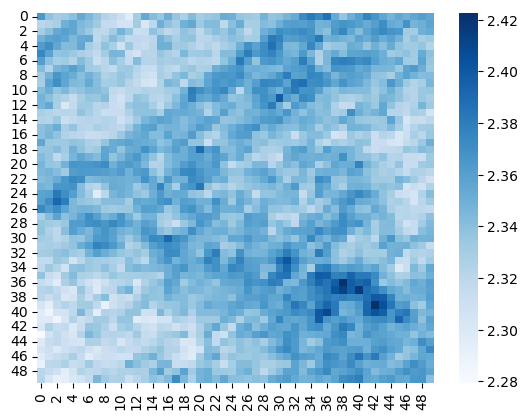

In [13]:
#水蒸気量の最小二乗法の実行
#1025.915-1238.245nm
H,W,C= img_slice.shape
out_h2o = np.empty((H,W,1))
for y in range(H):
    print(y)
    for x in range(W):
        data_rad = get_radiance(img_slice, param, y, x)
        df = pd.DataFrame(data_rad, columns=["Wavelength", "Radiance"])
        if np.max(df.iloc[:,1]) == 0:
            out_h2o[y,x,:] =  0
        else:
            b = estimate_param_h2o(data_h2o, df)
            a0 =  np.array([6.5, 0, 0, b, 4.0, 0.0])
            res = least_squares(residuals_h2o, a0, args=(data_h2o, df), method="lm")
            out_h2o[y,x,:] =  res.x[4]
sns.heatmap(out_h2o[:, :, 0], cmap="Blues")
print(np.average(out_h2o))

In [13]:
water_ave = f"{np.average(out_h2o) :.4f}"
for i in range(0, 7):
    json_open = open(r"C:\Users\Public\Documents\MODTRAN6\matusoka\example\sample\sample.json")
    json_load = json.load(json_open) #サンプルコードを持ってくる
    num = f"{20 * i + 380}" #0.25ずつH20を増やす
    num_str = str(num)
    water = str(water_ave)
    water_str = water.replace('.', 'p')
    file_name = water_str + "_" + num_str + "ppm"
    file_name_csv = file_name + '.csv' 
    file_name_json = file_name + '.json' 
    file_path = os.path.join(directory, "CO2", file_name)  
    os.makedirs(file_path, exist_ok=True) #新しくフォルダを作成
    json_load['MODTRAN'][0]['MODTRANINPUT']['NAME'] = file_name #sampleのファイル名を変更
    json_load['MODTRAN'][0]['MODTRANINPUT']['DESCRIPTION'] = '' #sampleの説明を変更
    json_load['MODTRAN'][0]['MODTRANINPUT']['RTOPTIONS']['IMULT'] = "RT_NO_MULTIPLE_SCATTER"
    del json_load['MODTRAN'][0]['MODTRANINPUT']['RTOPTIONS']['NSTR']
    del json_load['MODTRAN'][0]['MODTRANINPUT']['RTOPTIONS']['DISALB']
    json_load['MODTRAN'][0]["MODTRANINPUT"]['ATMOSPHERE']['H2OSTR'] = float(water_ave) #sampleのH20量を変更
    json_load['MODTRAN'][0]["MODTRANINPUT"]['ATMOSPHERE']['CO2MX'] = float(num)
    json_load['MODTRAN'][0]["MODTRANINPUT"]['ATMOSPHERE']['PROFILES'][4]['PROFILE'] = [float(num)] * int(json_load['MODTRAN'][0]["MODTRANINPUT"]['ATMOSPHERE']['NLAYERS'])
    #json_load['MODTRAN'][0]["MODTRANINPUT"]['ATMOSPHERE']['PROFILES'][4]['PRO_MASK'] = [2] *  int(json_load['MODTRAN'][0]["MODTRANINPUT"]['ATMOSPHERE']['NLAYERS'])
    del json_load['MODTRAN'][0]["MODTRANINPUT"]['ATMOSPHERE']['PROFILES'][4]['PRO_MASK']
    json_load['MODTRAN'][0]['MODTRANINPUT']['GEOMETRY']["BCKZEN"] = BCKZEN
    json_load['MODTRAN'][0]['MODTRANINPUT']['GEOMETRY']['IDAY'] = IDAY
    json_load['MODTRAN'][0]['MODTRANINPUT']['GEOMETRY']["PARM1"] = PARM1
    json_load['MODTRAN'][0]['MODTRANINPUT']['GEOMETRY']["PARM2"] = PARM2
    json_load['MODTRAN'][0]['MODTRANINPUT']['GEOMETRY']["GMTIME"] = GMTIME
    json_load['MODTRAN'][0]['MODTRANINPUT']['SURFACE']['TPTEMP'] = 305
    json_load['MODTRAN'][0]["MODTRANINPUT"]['FILEOPTIONS']['CSVPRNT'] = file_name_csv #sampleのcsvファイル名を変更
    json_path = os.path.join(directory, "CO2", file_name, file_name_json)  
    with open(json_path, "w") as f:
       json.dump(json_load, f, indent=4)
              
    modtran_command = [r'C:\Program Files\SSI\MODTRAN6\x86_64\mod6win.exe', json_path]
    process = subprocess.Popen(modtran_command, shell=True)
    try:
        time.sleep(15)
        if process.poll() is None:
            process.terminate()  # 優先的にterminate()で終了
            process.wait()  # プロセスが完全に終了するまで待機
    except Exception as e:
        print('Error while terminating MODTRAN.')
    finally:
        if process.poll() is None:
            process.kill()
        print('MODTRAN process of ', file_name ,'ended.')

MODTRAN process of  4p8141_380ppm ended.
MODTRAN process of  4p8141_400ppm ended.
MODTRAN process of  4p8141_420ppm ended.
MODTRAN process of  4p8141_440ppm ended.
MODTRAN process of  4p8141_460ppm ended.
MODTRAN process of  4p8141_480ppm ended.
MODTRAN process of  4p8141_500ppm ended.


In [14]:
data_co2 = []

for i in range(0, 7):
    num = f"{20 * i + 380}" 
    num_str = str(num)
    water = str(water_ave)
    water_str = water.replace('.', 'p')
    file_name = water_str + "_" + num_str + "ppm"
    file_name_csv = file_name + '_scan.csv'
    file_pass =  os.path.join(directory, 'CO2' , file_name, file_name_csv)
    data = pd.read_csv(file_pass, skiprows=[0,1,2,3,5], skipfooter=1, engine='python')
    if i == 0 :
        list_wave = data['Waveln'].tolist()
        data_co2.append(list_wave)
    list_total_co2 = data['  total'].tolist()
    data_co2.append(list_total_co2)
data_co2 = np.array(data_co2)
data_co2_T = np.array(data_co2).T
header = ["Waveln"]
for i in range(0,7):
    num = f"{20 * i + 380}"
    header.append(num)
data_name = water_str + '.csv'
data_pass = os.path.join(directory, data_name)
with open(data_pass, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(header)
    writer.writerows(data_co2_T)
data_co2[1:,:] = data_co2[1:,:] * 100

In [ ]:
#装置関数と二酸化炭素の最小二乗法
def extract_co2(data): #範囲の選択
    return data[:, 1657:1709]

def estimated_by_co2(data, c): #二酸化炭素の量の推定, 5.0ppm刻みの水を線形補間
    co2 = np.arange(380, 380 + 20.0 * (data.shape[0]-1), 20.0)
    position = np.searchsorted(co2, c)
    out = []
    for i in range(data.shape[1]):
        if position + 1 < data.shape[0]:  # インデックスが範囲外にならないようにチェック
            r = (co2[position] - c) / 20.0
            interpolated_value = r * data[position, i] + (1 - r) * data[position + 1, i]
        else:
            interpolated_value = data[position, i]  # 最後のインデックスの場合、次の値がないためそのままの値を使用
        out.append(interpolated_value)
    return out

def wavelength_adjustment_co2(data_co2, array, data_hisui):  #波長を線形補間する
    out = []
    wave_width = 1.0 #ここで波長の刻み幅を変える
    for i in range(91,96): 
        position = np.searchsorted(array, data_hisui.iloc[i, 0]) #水の場所を求める
        r = (array[position] - data_hisui.iloc[i, 0]) / wave_width 
        out.append(r * data_co2[position - 1] + (1 - r) * data_co2[position])
    return out

def func_co2(data, data_hisui, sigma, mu, a, b, c):  #目的関数
    out = instrumental_function(data, sigma, mu)
    out = extract_co2(out)
    out = reflectance_correction(out, a, b)
    out = estimated_by_co2(out, c)
    out = wavelength_adjustment_co2(out, data[0, 1657:1709], data_hisui)
    return out

def residuals_co2(param, data, data_hisui):  #残差
    sigma, mu, a, b, c = param
    w_est = func_co2(data, data_hisui, sigma, mu, a, b, c)
    return data_hisui.iloc[91:96,1] - w_est

def estimate_param_co2(data, data_hisui): #bの推定
    out = instrumental_function(data, sigma=7.0, mu=0.0)
    out = extract_co2(out)
    out = estimated_by_co2(out, c=420)
    out = wavelength_adjustment_co2(out, data[0, 1657:1709], data_hisui)
    out = np.array(out)
    highlight_points = [0, 4] #2037.605, 2087.565nm
    x = data_hisui.iloc[91:96, 0].iloc[highlight_points]
    y = data_hisui.iloc[91:96, 1].iloc[highlight_points] / out[highlight_points]
    coefficients = np.polyfit(x, y, 1)
    return coefficients #[0]がb, [1]がaとなることに注意 

def estimate_param_co2(data, data_hisui): #bの推定
    max_ref = max(data_hisui.iloc[91:96,1]) #2037.605-2087.565nm
    rel_max_index = np.argmax(data_hisui.iloc[91:96,1])
    abs_max_index = data_hisui.iloc[91:96].index[rel_max_index]
    max_wave = data_hisui.iloc[abs_max_index, 0]
    out = instrumental_function(data, sigma=6.5, mu=0.0)
    out = extract_co2(out)
    out = estimated_by_co2(out, c=420)
    out = wavelength_adjustment_co2(out, data[0, 1657:1709], data_hisui)
    modtran = out[rel_max_index]
    b = max_ref / max_wave / modtran
    return b

In [ ]:
#装置関数と二酸化炭素量の最小二乗法の実行
#1950.175-2100.055nm
H,W,C= img_slice.shape
out_co2 = np.empty((H,W,5))
for y in range(H):
    print(y)
    for x in range(W):
        data_rad = get_radiance(img_slice, param, y, x)
        df = pd.DataFrame(data_rad, columns=["Wavelength", "Radiance"])
        if np.max(df.iloc[:,1]) == 0:
            out_co2[y,x,:] =  0
        else:
            b, a = estimate_param_co2(data_co2, df)
            a0 =  np.array([7.0, 0.0, a, b, 420])
            res = least_squares(residuals_co2, a0, args=(data_co2, df), method="lm")
            out_co2[y,x,0] =  res.x[0] #sigma
            out_co2[y,x,1] =  res.x[1] #mu
            out_co2[y,x,2] =  res.x[2] #a
            out_co2[y,x,3] =  res.x[3] #b
            out_co2[y,x,4] =  res.x[4] #co2


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29


The average of sigma is  7.4190028152777385
The average of CO2 is  439.97651089068205


Text(0.5, 1.0, 'Amounts of CO2')

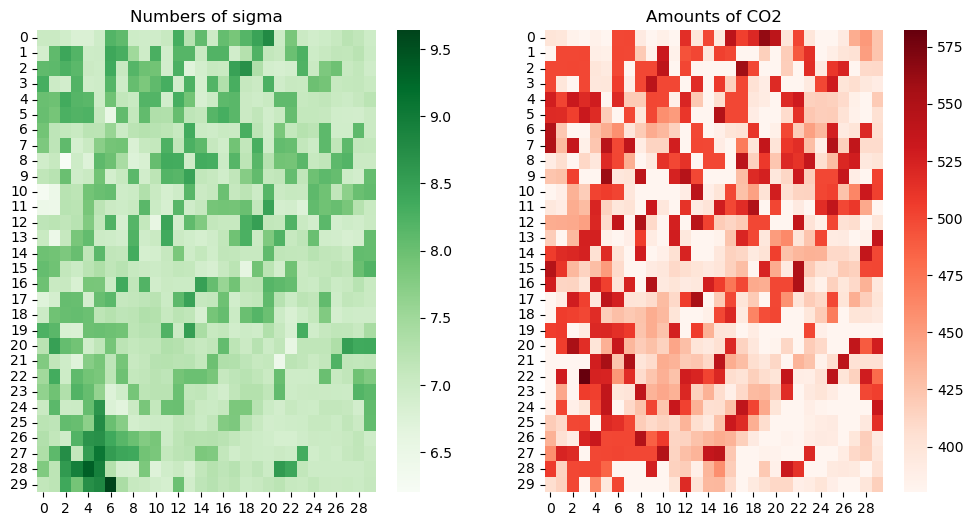

In [17]:
print("The average of sigma is ", np.average(out_co2[:, :, 0]))
print("The average of CO2 is ", np.average(out_co2[:, :, 4]))

fig, axes = plt.subplots(1, 2, figsize=(12,6))
sns.heatmap(out_co2[:, :, 0], cmap="Greens", ax=axes[0])
axes[0].set_title("Numbers of sigma")
sns.heatmap(out_co2[:, :, 4], cmap="Reds", ax=axes[1])
axes[1].set_title("Amounts of CO2")

In [18]:
#二酸化炭素量の最小二乗法
sigma_co2 = np.average(out_co2[:, :, 0])

def func_co2_rev(data, data_hisui, mu, a, b, c):  #目的関数
    out = instrumental_function(data, sigma_co2, mu)
    out = extract_co2(out)
    out = reflectance_correction(out, a, b)
    out = estimated_by_co2(out, c)
    out = wavelength_adjustment_co2(out, data[0, 1657:1709], data_hisui) #2037-2088nm
    return out

def residuals_co2_rev(param, data, data_hisui):  #残差
    mu, a, b, c = param
    w_est = func_co2_rev(data, data_hisui, mu, a, b, c)
    return data_hisui.iloc[91:96,1] - w_est #2037.605-2087.565nm

In [19]:
#二酸化炭素量の最小二乗法の実行
#2037.605-2087.565nm
H,W,C= img_slice.shape
out_co2_rev = np.empty((H,W,4))
for y in range(H):
    print(y)
    for x in range(W):
        data_rad = get_radiance(img_slice, param, y, x)
        df = pd.DataFrame(data_rad, columns=["Wavelength", "Radiance"])
        if np.max(df.iloc[:,1]) == 0:
            out_co2[y,x,:] =  0
        else:
            b,a = estimate_param_co2(data_co2, df)
            a0 =  np.array([0.0, a, b, 420])
            res = least_squares(residuals_co2_rev, a0, args=(data_co2, df), method="lm")
            out_co2_rev[y,x,0] =  res.x[0] #mu
            out_co2_rev[y,x,1] =  res.x[1] #a
            out_co2_rev[y,x,2] =  res.x[2] #b
            out_co2_rev[y,x,3] =  res.x[3] #co2

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29


The average of CO2 is  431.6814188087516
478.79942475271736
379.99944670026935


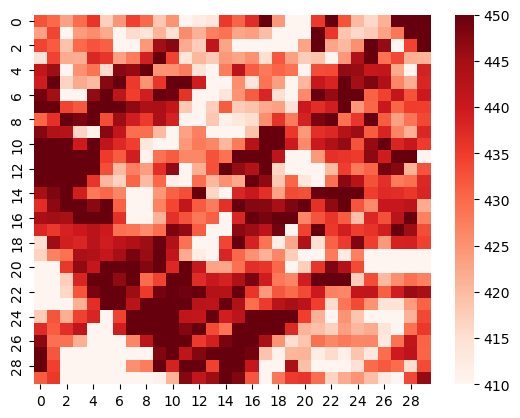

In [20]:
print("The average of CO2 is ", np.average(out_co2_rev[:, :, 3]))
sns.heatmap(out_co2_rev[:, :, 3], cmap="Reds", vmin=410, vmax=450)
print(np.max(out_co2_rev[:, :, 3]))
print(np.min(out_co2_rev[:, :, 3]))